In [28]:
# 필요한 함수들 정의
from tqdm import tqdm
import time
import numpy as np
import random
import hnswlib
from tqdm import tqdm
import time
import json
import os 
import struct
# 데이터셋 불러오는 블록

dataset_name ="sift1m"
# dataset_name ="HnM"
# dataset_name ="ArXiv"

original_data_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}_original"
num_attribute = 3
cardinality = [12] * num_attribute
distribution = "random"
# distribution = "zipf"

# sort_hardness = "Hardness"
# sort_hardness = "Pre_Hardness"
# sort_hardness = "Post_Hardness"

sort_hardness = "mul"
# sort_hardness = "sum"
# sort_hardness = "harmonic"
# sort_hardness = "geometric"
# sort_hardness = "weighted_sum"; weight_param = [0.5,0.5]




# sort_hardness = "selectivity"
# sort_hardness = "correlation"
# sort_hardness = "select_corr_combine"


##################################################################################################
if sort_hardness == "selectivity" or sort_hardness == "correlation" or sort_hardness == "select_corr_combine":
    baseline = 1
else:
    baseline = 0

if dataset_name == "sift1m":
    cardi = '_'.join(str(c) for c in cardinality)
    data_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}_A{num_attribute}_{cardi}_{distribution}"
    hardness_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}_A{num_attribute}_{cardi}_{distribution}/hardness_format"
    mid_format = os.path.join(data_path,"mid_format")
    query_fvecs_path = os.path.join(original_data_path, "sift_query.fvecs")
    query_label_path = os.path.join(data_path, "mid_format/query_label.txt")
    base_vector_path = os.path.join(data_path, "mid_format/base_vector.bin")
    base_label_path = os.path.join(data_path, "mid_format/base_label_UNG.txt")
    # hardness_json_path = os.path.join(data_path, "hardness/hardness_v3.0_10000.json")

elif dataset_name == "HnM": 
    data_path=f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}"
    hardness_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}/hardness_format"
    mid_format = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}/mid_format"
    query_fvecs_path = os.path.join(mid_format, "query_vector.fvecs")
    query_label_path = os.path.join(mid_format, "query_label.txt")
    
    base_vector_fvecs = os.path.join(mid_format, "base_vector.fvecs")
    base_vector_path = os.path.join(mid_format, "base_vector.bin")    
    base_label_path = os.path.join(mid_format, "base_label.txt")
    # hardness_json_path = os.path.join(data_path, "hardness/hardness_v3.0_10000.json")

elif dataset_name == "Arxiv":
    data_path=f"/home/mintaek/hybrid_index/Benchmark/ArXiv/medium/include"
    hardness_path = f"/home/mintaek/hybrid_index/Benchmark/ArXiv/medium/include/hardness_format"
    mid_format = f"/home/mintaek/hybrid_index/Benchmark/ArXiv/medium/include/mid_format"
    query_fvecs_path = os.path.join(mid_format, "query_vector.fvecs")
    query_label_path = os.path.join(mid_format, "query_label.txt")
    
    base_vector_fvecs = os.path.join(mid_format, "base_vector.fvecs")
    base_vector_path = os.path.join(mid_format, "base_vector.bin")
    base_label_path = os.path.join(mid_format, "base_label.txt")
    # hardness_json_path = os.path.join(data_path, "hardness/hardness_v3.0_10000.json")

DATA_DIR = hardness_path



def read_fvecs(filename):
    with open(filename, "rb") as f:
        data = []
        while True:
            dim_bytes = f.read(4)
            if not dim_bytes:
                break
            dim = struct.unpack('i', dim_bytes)[0]
            vec = np.frombuffer(f.read(4 * dim), dtype=np.float32)
            data.append(vec)
        return np.vstack(data)

def load_groundtruth_bin(filename, nq):
    record_dtype = np.dtype([("idx", np.uint32), ("dist", np.float32)])
    file_size = os.path.getsize(filename)
    record_size = record_dtype.itemsize  # 8 bytes (4+4)
    total_recs = file_size // record_size

    if nq == 0 or total_recs % nq != 0:
        raise ValueError(f"GT file size mismatch: total_recs={total_recs}, nq={nq}")

    K_gt = total_recs // nq

    data = np.fromfile(filename, dtype=record_dtype, count=total_recs)
    # 인덱스만 추출, shape: (nq, K_gt)
    gt_indices = data["idx"].reshape(nq, K_gt)
    return gt_indices

vectors_file = f"{DATA_DIR}/vectors.npy"
# payloads_file = f"{DATA_DIR}/payloads.jsonl"
# tests_file = f"{DATA_DIR}/tests.jsonl"

# ------------------------------------
# 1. Load vectors.npy
# ------------------------------------
vectors = np.load(vectors_file)
print("vectors.shape =", vectors.shape)

base_labels_1 = []
with open(os.path.join(mid_format, "base_label.txt"), "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:        # 빈 줄 스킵
            continue
        nums = [int(x) for x in line.split(",") if x.strip()]
        base_labels_1.append(nums)

base_labels = []
for l in base_labels_1:
    temp = set(l)
    base_labels.append(temp)

print(f"총 {len(base_labels)}개 라벨 로드됨")
# print("예시:", labels[0])


queries = read_fvecs(query_fvecs_path)
print("queries.shape =", queries.shape)

query_labels_1 = []
with open(os.path.join(mid_format, "query_label.txt"), "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:        # 빈 줄 스킵
            continue
        nums = [int(x) for x in line.split(",") if x.strip()]
        query_labels_1.append(nums)

query_labels = []
for l in query_labels_1:
    temp = set(l)
    query_labels.append(temp)

print(f"총 {len(query_labels)}개 라벨 로드됨")

gt = load_groundtruth_bin(os.path.join(mid_format,"gt.bin"), 10000)
print("gt.shape =", gt.shape)

vectors.shape = (1000000, 128)
총 1000000개 라벨 로드됨
queries.shape = (10000, 128)
총 10000개 라벨 로드됨
gt.shape = (10000, 10)


In [29]:
def pre_filtering(base_vectors, base_labels, query_vectors, query_labels, K):
    """
    base_vectors : np.ndarray of shape (N, D)
    base_labels  : list of set(), length N
    query_vectors: np.ndarray of shape (Q, D)
    query_labels : list of set(), length Q
    K            : int, number of nearest neighbors to return
    
    Returns:
        results: list of list of int
                 results[q] = indices of top-K nearest base vectors for query q
    """
    results = []
    filtered_count = []
    for query_vector, query_label in tqdm(zip(query_vectors, query_labels)):
        # 1️⃣ label-based filtering
        
        
        filtered_ids = []
        for i, bl in enumerate(base_labels):
            if query_label.issubset(bl):
                filtered_ids.append(i)

        # filtered_ids = [
        #     i for i, base_label in enumerate(base_labels)
        #     # if base_label.issuperset(query_label)
        #     if query_label.issubset(base_label)
        # ]
        ###################
        # results.append(filtered_ids)
        ###################

        if not filtered_ids:
            results.append([])  # no candidate satisfies filter
            continue
        
        filtered_count.append(len(filtered_ids))        

        # 2️⃣ distance computation (L2 distance)
        filtered_vectors = base_vectors[filtered_ids]
        dists = np.linalg.norm(filtered_vectors - query_vector, axis=1)
        
        # 3️⃣ get top-K smallest distances
        topk_idx = np.argsort(dists)[:K]
        topk_global_ids = [filtered_ids[i] for i in topk_idx]
        
        results.append(topk_global_ids)
    
    return results, sum(filtered_count) / len(filtered_count)

        
import numpy as np

TRASH = 4294967295

def recall_at_k(retrieved, gt, k):
    """
    - 단일 쿼리:
        retrieved: [int, ...]
        gt       : [int, ...] or set/np.array
        return   : float
    - 배치 쿼리:
        retrieved: [[int,...], [int,...], ...]
        gt       : [[int,...], [int,...], ...]
        return   : float (배치 평균)
    """

    def _to_list(x):
        if isinstance(x, (set, tuple)):
            return list(x)
        if isinstance(x, np.ndarray):
            return x.tolist()
        return x

    def _single_recall(r, g):
        r = _to_list(r) if r is not None else []
        g = _to_list(g) if g is not None else []

        # 유효 GT 정제 (trash 제거)
        filtered_gt = [x for x in g if x != TRASH]

        # 유효 GT 없으면 recall 1.0
        if not filtered_gt:
            return 1.0

        return len(set(r) & set(filtered_gt)) / min(len(filtered_gt), k)

    # 배치 여부 판별
    is_batch = (
        isinstance(retrieved, (list, tuple, np.ndarray)) and
        len(retrieved) > 0 and
        isinstance(retrieved[0], (list, tuple, set, np.ndarray))
    )

    if is_batch:
        gt = gt if gt is not None else []
        recalls = []
        for r_i, g_i in zip(retrieved, gt):
            recalls.append(_single_recall(r_i, g_i))
        return sum(recalls) / len(recalls) if recalls else 0.0
    else:
        return _single_recall(retrieved, gt)



In [30]:
# 1. Load hardness and GT
space = "l2"
# space = "cosine"

if baseline == 1:
    hardness_path = os.path.join(data_path, "hardness/hardness_baseline_10000.json")
else:
    hardness_path = os.path.join(data_path, "hardness/hardness_v3.3_10000.json")

with open(hardness_path) as f:
    hardness_data = json.load(f)


if sort_hardness == "mul":
    hardness = np.array([item["Pre_Hardness"] * item["Post_Hardness"] for item in hardness_data])

elif sort_hardness == "sum":
    hardness = np.array([item["Pre_Hardness"] + item["Post_Hardness"] for item in hardness_data])

elif sort_hardness == "harmonic":
    hardness = np.array([
        (2 * item["Pre_Hardness"] * item["Post_Hardness"]) / (item["Pre_Hardness"] + item["Post_Hardness"])
        if (item["Pre_Hardness"] + item["Post_Hardness"]) != 0 else 0
        for item in hardness_data
    ])

elif sort_hardness == "geometric":
    hardness = np.array([
        (item["Pre_Hardness"] * item["Post_Hardness"]) ** 0.5
        for item in hardness_data
    ])

elif sort_hardness == "weighted_sum":
    w_post, w_pre = weight_param[0], weight_param[1]
    hardness = np.array([
        w_pre * item["Pre_Hardness"] + w_post * item["Post_Hardness"]
        for item in hardness_data
    ])

else: 
    hardness = np.array([item[sort_hardness] for item in hardness_data])

# hardness = np.array([item[sort_hardness] for item in hardness_data])
sorted_idx = np.argsort(hardness)


# 정렬된 순서대로 queries, gt 재정렬
queries_sorted = [queries[i] for i in sorted_idx]
query_labels_sorted = [query_labels[i] for i in sorted_idx]
gt_sorted = [gt[i] for i in sorted_idx]


# 배치 크기와 개수
batch_size = 1000
num_batches = len(sorted_idx) // batch_size  # = 10

query_batches = []
gt_batches = []
query_label_batches = []

for i in range(num_batches):
    start = i * batch_size
    end = (i + 1) * batch_size
    query_batches.append(queries_sorted[start:end])
    gt_batches.append(gt_sorted[start:end])
    query_label_batches.append(query_labels_sorted[start:end])

print(f"총 {num_batches}개 배치 생성됨. 각 배치당 {batch_size}개 query.")

총 10개 배치 생성됨. 각 배치당 1000개 query.


In [31]:
# batch_stats = []

# batch_idx = 0
# t1 = time.time()
# result = pre_filtering(vectors, base_labels, query_batches[batch_idx], query_label_batches[batch_idx], K = 10)
# t2 = time.time()
# recall = recall_at_k(result, gt_batches[batch_idx], 10)
# batch_stats.append({
#         'batch': batch_idx,
#         'qps': 1000 / (t2 - t1),
#         'avg_recall': recall,
#     })

In [32]:
# batch_stats = []

# batch_idx = 0
# t1 = time.time()
# result = pre_filtering(vectors, base_labels, queries[:1000], query_labels[:1000], K = 10)
# t2 = time.time()
# recall = recall_at_k(result, gt[:1000], 10)
# batch_stats.append({
#         'batch': batch_idx,
#         'qps': 1000 / (t2 - t1),
#         'avg_recall': recall,
#     })

In [33]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import time

def process_batch(batch_idx, vectors, base_labels, query_batches, query_label_batches, gt_batches, K):
    """단일 배치 작업"""
    t1 = time.time()
    result, avg_filtered_ids = pre_filtering(vectors, base_labels,
                           query_batches[batch_idx],
                           query_label_batches[batch_idx],
                           K=K)
    t2 = time.time()
    recall = recall_at_k(result, gt_batches[batch_idx], K)
    return {
        'batch': batch_idx,
        'qps': 1000 / (t2 - t1),
        'avg_recall': recall,
        'avg_filtered_ids': avg_filtered_ids,
    }

# ---- 병렬 실행 ----
batch_stats = []
num_workers = 10  # 코어 개수에 맞게 조정

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    futures = [
        executor.submit(process_batch, i, vectors, base_labels,
                        query_batches, query_label_batches, gt_batches, 10)
        for i in range(len(query_batches))
    ]

    for f in as_completed(futures):
        batch_stats.append(f.result())

# batch_stats를 batch 인덱스 순으로 정렬
batch_stats.sort(key=lambda x: x['batch'])


1000it [01:17, 12.93it/s]
1000it [01:56,  8.58it/s]
1000it [02:13,  7.50it/s]
1000it [02:17,  7.29it/s]
1000it [02:26,  6.82it/s]
1000it [02:16,  7.32it/s]
1000it [03:16,  5.10it/s]
1000it [03:18,  5.05it/s]
1000it [03:20,  4.99it/s]
1000it [03:14,  5.13it/s]


In [34]:
# batch_stats = []
# for batch_idx in range(len(query_batches)):
#     t1 = time.time()
#     result, avg_filtered_len = pre_filtering(vectors, base_labels, query_batches[batch_idx], query_label_batches[batch_idx], K = 10)
#     t2 = time.time()
#     recall = recall_at_k(result, gt_batches[batch_idx], 10)
#     batch_stats.append({
#             'batch': batch_idx,
#             'qps': 1000 / (t2 - t1),
#             'avg_recall': recall,
#             'avg_filtered_len': avg_filtered_len,
#         })

In [35]:
import os

pre_filter_path = os.path.join(data_path, "pre_filter_format")
os.makedirs(pre_filter_path, exist_ok=True)
output_file = os.path.join(pre_filter_path, f"{sort_hardness}_search_results.txt")

with open(output_file, "w") as f:
    # 헤더 작성
    f.write("Batch\tQPS\tAvg_Recall\tAvg_Filtered_Len\n")

    # batch_stats의 각 항목을 한 줄씩 기록
    for stat in batch_stats:
        f.write(f"{stat['batch']}\t"
                f"{stat['qps']:.4f}\t"
                f"{stat['avg_recall']:.4f}\t"
                f"{stat['avg_filtered_ids']:.4f}\n")

print(f"[✓] pre_filter 결과 저장 완료 (Batch 기준 정렬): {output_file}")


[✓] pre_filter 결과 저장 완료 (Batch 기준 정렬): /home/mintaek/hybrid_index/Benchmark/sift1m_A3_12_12_12_random/pre_filter_format/mul_search_results.txt


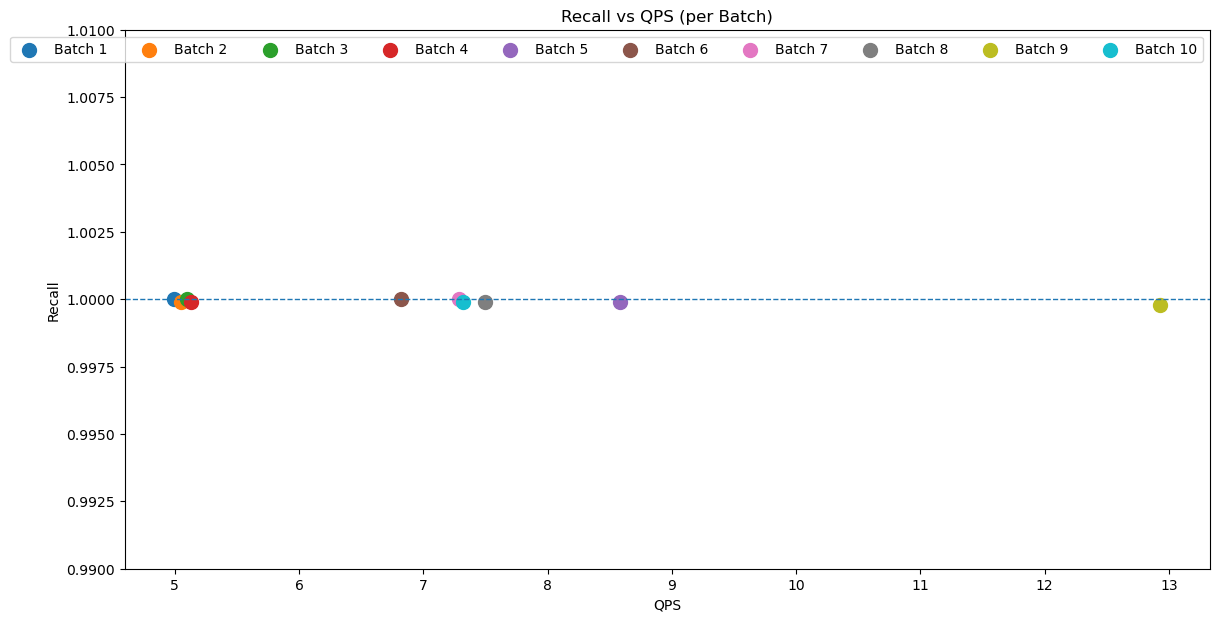

/home/mintaek/hybrid_index/Benchmark/sift1m_A3_12_12_12_random
mul


In [36]:
## pre filtering graph 그리기

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

colors = plt.cm.tab10.colors

plt.figure(figsize=(14, 7))

for d in batch_stats:
    plt.scatter(float(d['qps']), float(d['avg_recall']), color=colors[d['batch'] % 10], s=100, label=f'Batch {d["batch"]+1}')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    by_label.values(),
    by_label.keys(),
    # title="Batch",
    loc='upper right',
    fontsize=10,  # ★ 여기서 폰트 사이즈 조절
    ncol=10   # ★ legend를 1행으로 만듦 (batch가 10개니까 ncol=10)
)

ax = plt.gca()

# 1) y=1 기준선
ax.axhline(1.0, linestyle='--', linewidth=1)

# 2) 배치 리콜에서 범위 계산해 1을 중앙에 두기
ys = [s['avg_recall'] for s in batch_stats]
center = 1.0
half_span = max(0.01, 1.1 * max(abs(center - min(ys)), abs(max(ys) - center)))
ax.set_ylim(center - half_span, center + half_span)

# 3) y축의 "+1" 오프셋 표시 제거
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='y', useOffset=False)

ax.set_xlabel('QPS')
ax.set_ylabel('Recall')
ax.set_title('Recall vs QPS (per Batch)')


pig_path = os.path.join(pre_filter_path, f"{sort_hardness}.png")
plt.savefig(pig_path, dpi=300)
plt.show()

print(data_path)
print(sort_hardness)